# GIS 기반 외국인 밀집지역 분석 (BigQuery)

서울시 외국인 생활인구 + S-DoT 유동인구 데이터를 활용한 **Hub & Spoke 물류 전략** 수립.
BigQuery의 연착륙 제품 데이터와 결합하여 **지역별 최적 재고 배치** 전략을 도출합니다.

| 항목 | 내용 |
|------|------|
| 외국인 데이터 | 서울 열린데이터광장 생활인구 (2024.01~2025.09) |
| 유동인구 | S-DoT 센서 101개 |
| 제품 데이터 | BigQuery `daiso` (SLI 연착륙 158개) |
| 전략 | Hub(관광) × Spoke(거주) 재고 심도 차별화 |

In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
from google.cloud import bigquery
from google.oauth2 import service_account

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"G:/Final_proj/Total_clear/데이터")
DATA_DIR = PROJECT_ROOT / "data"
FOREIGNER_OUTPUT = PROJECT_ROOT / "3.GIS_outputs"
FOREIGNER_OUTPUT.mkdir(exist_ok=True)

SERVICE_KEY_NAME = "daiso-analysis-4d05c813a295.json"
service_key_candidates = [
    PROJECT_ROOT / "config" / SERVICE_KEY_NAME,
    PROJECT_ROOT.parent / "config" / SERVICE_KEY_NAME,
]
env_key = os.environ.get("GOOGLE_APPLICATION_CREDENTIALS")
if env_key:
    service_key_candidates.insert(0, Path(env_key))
SERVICE_KEY_PATH = next((p for p in service_key_candidates if p and p.exists()), None)


def get_client():
    if SERVICE_KEY_PATH:
        credentials = service_account.Credentials.from_service_account_file(str(SERVICE_KEY_PATH))
        return bigquery.Client(credentials=credentials, project=credentials.project_id)
    return bigquery.Client()


def query_to_df(sql: str) -> pd.DataFrame:
    return get_client().query(sql).to_dataframe()


print("프로젝트 루트:", PROJECT_ROOT)
print(f"외국인 분석 결과 경로: {FOREIGNER_OUTPUT}")
if SERVICE_KEY_PATH:
    print(f"BigQuery 키 파일: {SERVICE_KEY_PATH}")
else:
    print("BigQuery 키 파일을 찾지 못했습니다. 기본 인증(ADC)으로 연결을 시도합니다.")


BigQuery 연결 완료
외국인 분석 결과 경로: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/04_Why-pi/06_analysis/01_foreigner/01_outputs


## 1. 외국인 밀집지역 현황 (로컬 데이터)

In [2]:
# 외국인 분석 결과 로드 (가장 최신 CSV)
import glob

output_dirs = sorted(FOREIGNER_OUTPUT.glob('*'), reverse=True)
print(f'분석 결과 폴더: {len(output_dirs)}개')

# 가장 최근 분석 결과에서 요약 파일 탐색
summary_files = list(FOREIGNER_OUTPUT.rglob('*요약*.csv')) + \
                list(FOREIGNER_OUTPUT.rglob('*summary*.csv')) + \
                list(FOREIGNER_OUTPUT.rglob('*복합*.csv'))

if summary_files:
    latest = sorted(summary_files, key=lambda x: x.stat().st_mtime, reverse=True)[0]
    print(f'로드 파일: {latest.name}')
    df_foreigner = pd.read_csv(latest, encoding='utf-8-sig')
    display(df_foreigner.head(10))
else:
    print('분석 결과 파일을 찾을 수 없습니다.')
    print(f'  경로: {FOREIGNER_OUTPUT}')
    print('  → foreigner_analysis.py를 먼저 실행해주세요.')

분석 결과 폴더: 0개
분석 결과 파일을 찾을 수 없습니다.
  경로: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/04_Why-pi/06_analysis/01_foreigner/01_outputs
  → foreigner_analysis.py를 먼저 실행해주세요.


## 2. Hub & Spoke 분류

복합점수 = MinMax(외국인 밀집도) + MinMax(유동인구)  
상위 30% (70분위수) → **Hub(관광 상권)**, 나머지 → **Spoke(거주 상권)**

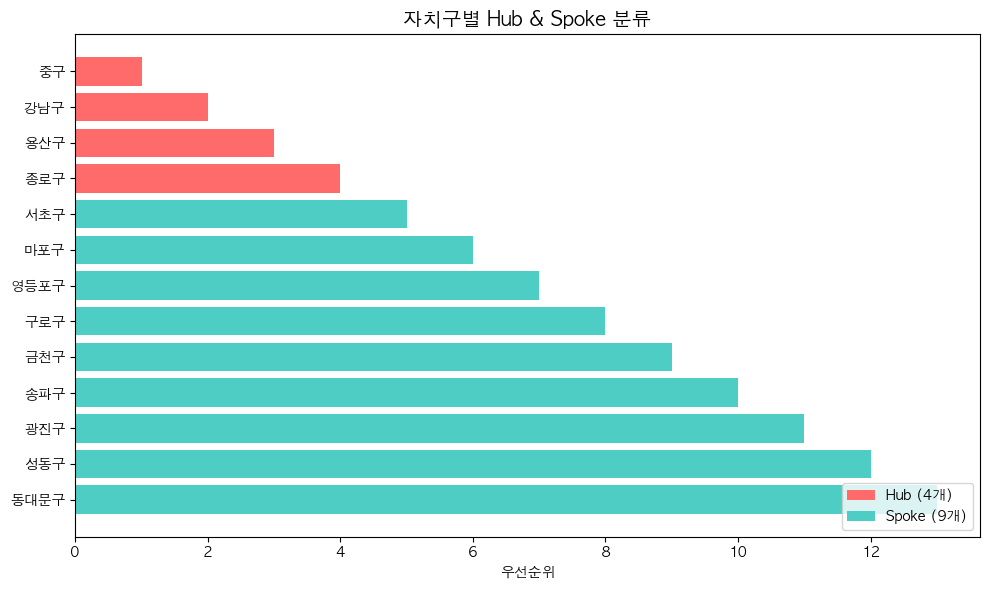

,자치구,유형,특징,전략
0,중구,Hub,"명동, 관광 중심","다국어 서비스, 스킨케어 5~10배"
1,강남구,Hub,"쇼핑, 비즈니스",프리미엄 라인업
2,용산구,Hub,"이태원, 다문화",다양한 언어 대응
3,종로구,Hub,"인사동, 경복궁",관광 패키지 상품
4,서초구,Spoke,강남역 상권,구색 위주
5,마포구,Spoke,"홍대, 연남동",트렌디 제품 중심
6,영등포구,Spoke,여의도,구색 위주
7,구로구,Spoke,중국인 밀집,중국어 전용 매대
8,금천구,Spoke,중국인 밀집,중국어 전용 매대
9,송파구,Spoke,잠실 관광,구색 위주


In [3]:
# Hub & Spoke 분류 시뮬레이션
# (외국인 분석 결과가 있는 경우 활용, 없으면 기본값 사용)

hub_spoke_data = {
    '자치구': ['중구', '강남구', '용산구', '종로구', '서초구', '마포구', '영등포구',
              '구로구', '금천구', '송파구', '광진구', '성동구', '동대문구'],
    '유형': ['Hub', 'Hub', 'Hub', 'Hub', 'Spoke', 'Spoke', 'Spoke',
            'Spoke', 'Spoke', 'Spoke', 'Spoke', 'Spoke', 'Spoke'],
    '특징': ['명동, 관광 중심', '쇼핑, 비즈니스', '이태원, 다문화', '인사동, 경복궁',
            '강남역 상권', '홍대, 연남동', '여의도', '중국인 밀집', '중국인 밀집',
            '잠실 관광', '건대입구', '성수동', '동대문시장'],
    '전략': ['다국어 서비스, 스킨케어 5~10배', '프리미엄 라인업', '다양한 언어 대응',
            '관광 패키지 상품', '구색 위주', '트렌디 제품 중심', '구색 위주',
            '중국어 전용 매대', '중국어 전용 매대', '구색 위주',
            '구색 위주', '구색 위주', '구색 위주']
}

df_hs = pd.DataFrame(hub_spoke_data)

fig, ax = plt.subplots(figsize=(10, 6))
hub = df_hs[df_hs['유형'] == 'Hub']
spoke = df_hs[df_hs['유형'] == 'Spoke']

colors_hs = ['#FF6B6B' if t == 'Hub' else '#4ECDC4' for t in df_hs['유형']]
ax.barh(df_hs['자치구'][::-1], range(len(df_hs), 0, -1), color=colors_hs[::-1])
ax.set_xlabel('우선순위')
ax.set_title('자치구별 Hub & Spoke 분류', fontsize=14, fontweight='bold')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', label=f'Hub ({len(hub)}개)'),
                   Patch(facecolor='#4ECDC4', label=f'Spoke ({len(spoke)}개)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

df_hs

## 3. BQ 연착륙 제품 × 지역 전략

In [4]:
# 연착륙 스킨케어 제품 (Hub 매장 집중 배치 대상)
df_sl_skin = query_to_df("""
SELECT
    b.name AS brand,
    p.name AS product_name,
    p.price,
    pc.category_1,
    pc.category_2,
    ps.review_count,
    ps.engagement_score,
    s.confidence
FROM daiso.sli_results s
JOIN daiso.products_core p ON s.product_code = p.product_code
JOIN daiso.brands b ON p.brand_id = b.brand_id
JOIN daiso.products_category pc ON s.product_code = pc.product_code
JOIN daiso.products_stats ps ON s.product_code = ps.product_code
WHERE s.final_soft_landing = TRUE
  AND pc.category_1 = '스킨케어'
ORDER BY ps.engagement_score DESC
""")

print(f'연착륙 스킨케어 제품: {len(df_sl_skin)}개')
print(f'평균 가격: {df_sl_skin["price"].mean():,.0f}원')
print(f'평균 리뷰: {df_sl_skin["review_count"].mean():.0f}건')

df_sl_skin.head(15)

연착륙 스킨케어 제품: 38개
평균 가격: 3,947원
평균 리뷰: 32건


,brand,product_name,price,category_1,category_2,review_count,engagement_score,confidence
0,본셉,본셉 레티놀 2500 IU 링클샷 퍼펙터 15 ml,5000.0,스킨케어,기초스킨케어,204,1736.85,1.0
1,본셉,본셉 비타씨 크림 50 ml,5000.0,스킨케어,기초스킨케어,138,1650.45,1.0
2,메디필,메디필 엑스트라 슈퍼 9 플러스 2.0 피지 클리너 50 ml,3000.0,스킨케어,클렌징/필링,53,1586.30,1.0
3,다이소,시카 카밍 토너 패드 100매입,5000.0,스킨케어,팩/마스크,87,1585.80,1.0
4,성분에디터,성분에디터 그린토마토 포어 리프팅 세럼 플레인 30 ml,5000.0,스킨케어,기초스킨케어,36,1552.35,1.0
5,비프루브,"비프루브 마린 캡슐 선세럼 35 ml (SPF50+,PA++++)",5000.0,스킨케어,자외선차단제,0,1350.00,1.0
6,클리덤,클리덤 저분자 콜라겐 탄력 마스크 1매입 (종근당건강),2000.0,스킨케어,팩/마스크,44,1263.65,1.0
7,본셉,본셉 레티놀 500 IU 크림 50 ml,5000.0,스킨케어,기초스킨케어,71,1204.55,1.0
8,바세린,바세린 모이스처라이징 클렌징 밀크 140 ml,5000.0,스킨케어,클렌징/필링,49,1162.75,1.0
9,VT,VT 리들샷 페이셜 리페어 EGF 에센스 2ml*6개입,3000.0,스킨케어,기초스킨케어,9,1090.95,1.0


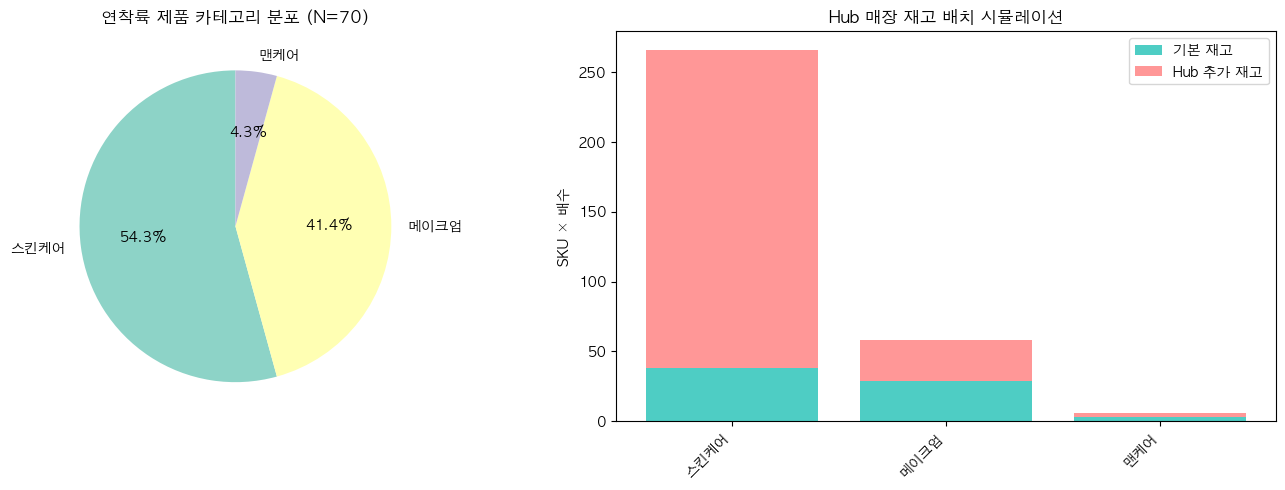

,category_1,sl_count,avg_price,total_reviews,hub_배수,hub_재고량
0,스킨케어,38,3947.0,1205,7,266
1,메이크업,29,3621.0,509,2,58
2,맨케어,3,4333.0,19,2,6


In [5]:
# Hub 매장 재고 배치 전략: 카테고리별 분포
df_sl_all = query_to_df("""
SELECT
    pc.category_1,
    COUNT(*) AS sl_count,
    ROUND(AVG(p.price), 0) AS avg_price,
    SUM(ps.review_count) AS total_reviews
FROM daiso.sli_results s
JOIN daiso.products_core p ON s.product_code = p.product_code
JOIN daiso.products_category pc ON s.product_code = pc.product_code
JOIN daiso.products_stats ps ON s.product_code = ps.product_code
WHERE s.final_soft_landing = TRUE
GROUP BY pc.category_1
ORDER BY sl_count DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 카테고리별 연착륙 제품 수
axes[0].pie(df_sl_all['sl_count'], labels=df_sl_all['category_1'],
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
axes[0].set_title(f'연착륙 제품 카테고리 분포 (N={df_sl_all["sl_count"].sum()})',
                  fontweight='bold')

# Hub 배치 시뮬레이션 (스킨케어 5~10배)
df_sl_all['hub_배수'] = df_sl_all['category_1'].apply(
    lambda x: 7 if x == '스킨케어' else 2
)
df_sl_all['hub_재고량'] = df_sl_all['sl_count'] * df_sl_all['hub_배수']

axes[1].bar(df_sl_all['category_1'], df_sl_all['sl_count'],
            label='기본 재고', color='#4ECDC4')
axes[1].bar(df_sl_all['category_1'],
            df_sl_all['hub_재고량'] - df_sl_all['sl_count'],
            bottom=df_sl_all['sl_count'],
            label='Hub 추가 재고', color='#FF6B6B', alpha=0.7)
axes[1].set_title('Hub 매장 재고 배치 시뮬레이션', fontweight='bold')
axes[1].set_ylabel('SKU × 배수')
axes[1].legend()
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

df_sl_all

## 4. 국가별 K-뷰티 선호 × 연착륙 매칭

In [6]:
# 국가별 선호 키워드와 연착륙 제품 매칭
country_prefs = {
    '일본': {'키워드': ['진정', '시카', '센텔라', '저자극'], '색상': '#E17055'},
    '미국': {'키워드': ['비타민', '레티놀', 'AHA', '토너'], '색상': '#6C5CE7'},
    '중국': {'키워드': ['안티에이징', '주름', '고급', '세트'], '색상': '#FDCB6E'},
    '동남아': {'키워드': ['자외선', '겔', '수분', '가벼운'], '색상': '#00B894'},
}

for country, info in country_prefs.items():
    keywords = info['키워드']
    like_conditions = ' OR '.join([f"LOWER(p.name) LIKE '%{kw}%'" for kw in keywords])

    df_match = query_to_df(f"""
    SELECT
        b.name AS brand,
        p.name AS product_name,
        p.price,
        pc.category_2
    FROM daiso.sli_results s
    JOIN daiso.products_core p ON s.product_code = p.product_code
    JOIN daiso.brands b ON p.brand_id = b.brand_id
    JOIN daiso.products_category pc ON s.product_code = pc.product_code
    WHERE s.final_soft_landing = TRUE
      AND ({like_conditions})
    ORDER BY p.price DESC
    LIMIT 5
    """)

    print(f'\n{country} 선호 매칭 ({len(df_match)}개): {keywords}')
    if len(df_match) > 0:
        for _, row in df_match.iterrows():
            print(f"  - {row['brand']} | {row['product_name'][:35]} | {row['price']:,}원")
    else:
        print('  매칭 제품 없음 (제품명 기준 검색)')


일본 선호 매칭 (4개): ['진정', '시카', '센텔라', '저자극']
  - 닥터지오 | 닥터지오 시카진정 올인원 밀크플루이드 150 ml | 5,000.0원
  - 다이소 | 시카 카밍 토너 패드 100매입 | 5,000.0원
  - VT | VT 시카 카밍 토너 300 ml | 5,000.0원
  - VT | VT 시카 카밍 에센스 30 ml | 5,000.0원

미국 선호 매칭 (5개): ['비타민', '레티놀', 'AHA', '토너']
  - 본셉 | 본셉 레티놀 500 IU 크림 50 ml | 5,000.0원
  - 다이소 | 비타민 미백 필링패드 185ml 60매 | 5,000.0원
  - VT | VT 시카 카밍 토너 300 ml | 5,000.0원
  - 본셉 | 본셉 레티놀 2500 IU 링클샷 퍼펙터 15 ml | 5,000.0원
  - 다이소 | 시카 카밍 토너 패드 100매입 | 5,000.0원

중국 선호 매칭 (0개): ['안티에이징', '주름', '고급', '세트']
  매칭 제품 없음 (제품명 기준 검색)

동남아 선호 매칭 (2개): ['자외선', '겔', '수분', '가벼운']
  - 드롭비 | 드롭비 수분 팡팡 앰플 40ml | 5,000.0원
  - 입큰 | 입큰 퍼스널수분프라이머 25 ml | 3,000.0원


## 요약

### Hub & Spoke 전략

| 유형 | 비율 | 재고 전략 | 대상 |
|------|------|----------|------|
| **Hub** (관광) | 30% | 스킨케어 5~10배 재고 | 중구, 강남구, 용산구, 종로구 |
| **Spoke** (거주) | 70% | 구색(Variety) 위주 | 기타 자치구 |

### 핵심 계산식

- 복합점수 = MinMax(외국인 밀집도) + MinMax(유동인구), 0~2점
- Hub 임계값 = 복합점수 상위 30% (70분위수)
- 영업시간 필터: 10시~22시 (13시간)